# Analisi esperimenti numerici

Un piccolo notebook per analizzare i dati degli esperimenti numerici, che salvo in un file `.csv`

## Imports, creazione del dataframe

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utilities import *
import optperfprofpy    

In [2]:
CSV_FILENAME = "bench-v0.1.3alpha-19_05.csv"

In [3]:
df = pd.read_csv(CSV_FILENAME)

In [4]:
df.shape

(1173, 25)

In [5]:
df.head()

,kind,n,eltype,approximant,algorithm,schur_time,alpha_time,eval_bound_time,eval_pade_time,squaring_time,...,cond_q,epsilon,rel_err_F,abs_err_1,nrm1_Ytrue,Ytrue_method,cond_expA_F,condA_1,condA_2,precision
0,rand,8,Float64,scaling_and_squaring,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.220446e-16,2.373560e-16,1.802861592277032e-14,80.90624298686493,diag_5120,4.871499,416.710942,183.633838,53
1,rand,8,Float64,diagonalcheap,transfree,0.000000,0.001778,2.846590,1.034318,2.247390e-04,...,1.599814,2.220446e-16,3.528458e-16,2.798910182946268e-14,80.90624298686493,diag_5120,4.871499,416.710942,183.633838,53
2,rand,8,Float64,diagonalcheap,transfree,0.000000,0.000163,0.001512,0.090343,3.100000e-08,...,23.980249,2.220446e-16,4.922147e-19,4.000962316205806e-17,80.90624298686493,diag_5120,4.871499,416.710942,183.633838,256
3,rand,8,Float64,diagonalcheap,transfree,0.000000,0.000217,0.050055,0.001716,4.100000e-08,...,23.980249,2.220446e-16,4.922147e-19,4.000962316205806e-17,80.90624298686493,diag_5120,4.871499,416.710942,183.633838,851
4,rand,8,Float64,diagonalcheap,complexschur,0.132116,0.000682,3.180894,1.082208,3.000000e-08,...,12.947847,2.220446e-16,1.357371e-15,1.304759016288776e-13,80.90624298686493,diag_5120,4.871499,416.710942,183.633838,53


## Descrizione colonne

In [6]:
df.columns

Index(['kind', 'n', 'eltype', 'approximant', 'algorithm', 'schur_time',
       'alpha_time', 'eval_bound_time', 'eval_pade_time', 'squaring_time',
       'total_time', 'm', 's', 'delta', 'psi', 'cond_q', 'epsilon',
       'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method', 'cond_expA_F',
       'condA_1', 'condA_2', 'precision'],
      dtype='object')

Ecco una descrizione delle colonne:
- `kind`: un identificativo del "tipo" di matrice che ha prodotto i risultati della riga corrispondente
- `n`: dimensione della matrice 
- `eltype`: tipo degli elementi della matrice
- `approximant`: approssimante scelta per il calcolo dell'esponenziale di matrice 
- `algorithm`: algoritmo usato da `exp_mp`. Può essere Schur reale, Schur complesso o niente Schur
- `schur_time`: tempo impiegato per calcolare la forma di Schur
- `alpha_time`: tempo totale impiegato per valutare l'$\alpha_{\min}$ in `exp_mp`
- `eval_bound_time`: tempo totale impiegato per valutare il bound sull'errore in `exp_mp`. Si osservi che la valutazione del bound può formare nuove potenze di $A$
- `eval_pade_time`: tempo totale impiegato nel valutare l'approssimante 
- `squaring_time`: tempo speso nella fase di squaring
- `total_time`: tempo totale impiegato dall'algoritmo (viene misurato direttamente. Non è la somma dei tempi precedenti)
- `m`: grado dell'approssimante scelto dall'algoritmo `exp_mp`
- `s`: fattore di scaling scelto dall'algoritmo `exp_mp` ($A$ viene scalata di $2^{-s}$)
- `delta`: valore finale di $\delta$ (ossia upper bound sull'errore) prodotto in `exp_mp`
- `psi`: valore finale di $\psi$ (ossia, stima di $\exp(A)$ usata stimare per l'errore relativo durante l'esecuzione di `exp_mp`)
- `cond_q`: valore finale del numero di condizionamento (in norma 1) di $q_m(2^{-s}A)$
- `epsilon`: valore $\epsilon$ usato per la tolleranza sull'errore relativo. Può essere passato in input, il valore di default è la precisione di macchina della precisione usata all'interno dell'algoritmo
- `rel_err_F`: accuratezza relativa della soluzione calcolata, in norma di Frobenius
- `abs_err_1`: errore assoluto della soluzione calcolata, in norma 1
- `nrm1_Ytrue`: norma 1 della soluzione di riferimento $Y_{\textup{true}}$ (considerata esatta nella valutazione dell'errore relativo)
- `Ytrue_method`: metodo usato per costruire $Y_{\textup{true}}$. La soluzione esatta può essere stata fornita insieme all'input $A$, o altrimenti può essere stata costruita per diagonalizzazione o eseguendo `exp_mp` in precisione più alta
- `cond_expA_F`: $\kappa_{\exp}(A)$, numero di condizionamento dell'esponenziale di $A$, in norma di Frobenius (se $A$ è troppo grande, il valore è `NaN`. Infatti il calcolo è "esatto")
- `condA_1`: $\kappa_1(A)$, numero di condizionamento di $A$ in norma 1
- `condA_2`: $\kappa_2(A)$, numero di condizionamento di $A$ in norma 2
- `precision`: il valore di precisione usato all'interno dell'algoritmo. Esso determina il valore della precisione di macchina $u$

## Analisi

In [7]:
df.columns

Index(['kind', 'n', 'eltype', 'approximant', 'algorithm', 'schur_time',
       'alpha_time', 'eval_bound_time', 'eval_pade_time', 'squaring_time',
       'total_time', 'm', 's', 'delta', 'psi', 'cond_q', 'epsilon',
       'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method', 'cond_expA_F',
       'condA_1', 'condA_2', 'precision'],
      dtype='object')

### Com'è stata ottenuta $Y_{\textup{true}}$?

In [12]:
ytrue_counts = df['Ytrue_method'].value_counts()
ytrue_percentages = (100 * ytrue_counts / df.shape[0]).round(2)

result = pd.DataFrame({
    'Count': ytrue_counts,
    'Percentage': ytrue_percentages
})

result

,Count,Percentage
Ytrue_method,,
diag_5120,799,68.12
exp_mp_5120,298,25.40
given,76,6.48


### $\delta$ è un upper bound?

Prima di tutto, concentriamoci su dove $\delta$ c'è. Ovvero, guardiamo a dove l'algoritmo è `exp_mp`

In [54]:
delta_present = df["delta"].dropna().index
df_delta = df.loc[delta_present]

La formula (3.14) di [hf19_mpexpm] legge:
$$
    \lvert\lvert\exp(X) - r_m(X)\rvert\rvert \le \lvert\lvert q_m(X)^{-1}\rvert\rvert\,\left\vert q_m(\alpha_d(X)e^{\alpha_d(X)}-p_m(\alpha_d(X))\right\vert\coloneqq\delta
$$


La domanda più pressante che mi viene in mente è: ma alla fine, $\delta$ è un upper bound all'errore, come rivendicano gli autori dell'articolo? 

***OSS***: Consideriamo che per il calcolo di un termine di $\delta$ si usa una stima della norma 1 eh...

In [45]:
from decimal import Decimal#, getcontext

delta_is_upper_bound_to_abserr = df_delta["abs_err_1"].map(Decimal) <= df_delta["delta"].map(Decimal)

print(f"abs_err <= delta in {sum(delta_is_upper_bound_to_abserr)} out of {df_delta.shape[0]} samples")

abs_err <= delta in 490 out of 950 samples


Parrebbe di no... Male. Molto male.

In [51]:

df_delta = df_delta[df_delta["kind"].isin(["rand","rand_big"])]

df_delta["abs_err_1"].describe()

count                        72
unique                       57
top       4.000962316205806e-17
freq                          2
Name: abs_err_1, dtype: object

In [66]:
pd.to_numeric(df_delta["abs_err_1"], errors='coerce').iloc[100]

np.float64(8.653964175055214e-15)

In [ ]:
min_value = y.min()
argmin_value = y.argmin()

print(f"min(y) = {min_value}")
print(f"argmin(y) = {argmin_value}")

NameError: name 'argmin' is not defined

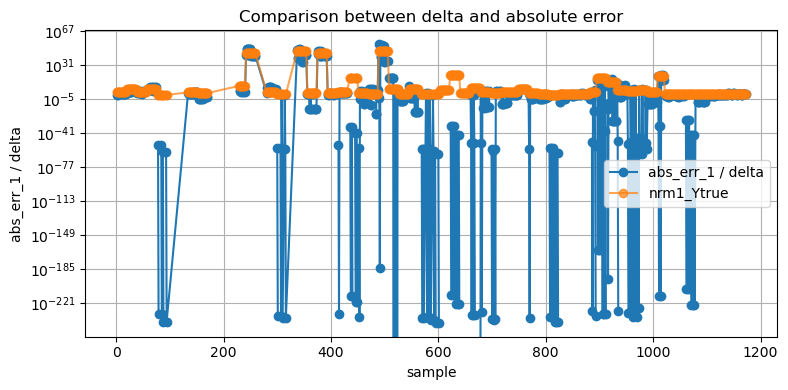

In [58]:
fig, ax = plt.subplots(figsize=(8,4))

#df_delta = df_delta[df_delta["kind"].isin(["rand","rand_big"])]

y = pd.to_numeric(df_delta["abs_err_1"], errors='coerce') / df_delta["delta"]
y2 = pd.to_numeric(df_delta["nrm1_Ytrue"], errors='coerce')

#y = df_delta["abs_err_1"].map(Decimal) / df_delta["delta"].map(Decimal)
#y2 = df_delta["nrm1_Ytrue"].map(Decimal)

ax.plot(y.index, y, marker='o', linestyle='-', label="abs_err_1 / delta")
ax.plot(y2.index, y2, marker='o', linestyle='-', alpha=0.7, label="nrm1_Ytrue")

ax.set_yscale('log')
ax.set_xlabel('sample')
ax.set_ylabel('abs_err_1 / delta')
ax.set_yscale('log')
ax.set_title('Comparison between delta and absolute error')
ax.legend()
ax.grid("True")

plt.tight_layout()
plt.show()

Quindi l'errore relativo e $\delta$ nemmeno sono così vicini!

Confrontando però il rapporto tra errore assoluto e $\delta$, pare che quest'ultimo approssimi l'errore relativo...

In [10]:
df.columns

Index(['kind', 'n', 'eltype', 'approximant', 'algorithm', 'schur_time',
       'alpha_time', 'eval_bound_time', 'eval_pade_time', 'squaring_time',
       'total_time', 'm', 's', 'delta', 'psi', 'cond_q', 'epsilon',
       'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'cond_expA_F', 'condA_1',
       'condA_2', 'precision'],
      dtype='object')

In [14]:
df_delta.loc[(df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"] > df_delta["delta"]), ["kind", "n", "algorithm", "approximant", "abs_err_1", "nrm1_Ytrue", "delta", "epsilon"]]

,kind,n,algorithm,approximant,abs_err_1,nrm1_Ytrue,delta,epsilon
4,randn,16,complexschur,diagonalcheap,3.651888e-11,4.741001e+03,1.429806e-15,2.220446e-16
7,randn,16,realschur,diagonalcheap,3.703048e-11,4.741001e+03,1.429806e-15,2.220446e-16
13,randn,16,complexschur,taylor,3.268195e-11,4.741001e+03,1.776357e-15,2.220446e-16
16,randn,16,realschur,taylor,3.316512e-11,4.741001e+03,1.776357e-15,2.220446e-16
23,randn,64,complexschur,diagonalcheap,2.010567e+00,9.775128e+13,3.112952e-15,2.220446e-16
26,randn,64,realschur,diagonalcheap,2.025460e+00,9.775128e+13,3.112952e-15,2.220446e-16
32,randn,64,complexschur,taylor,2.027657e+00,9.775128e+13,6.661338e-16,2.220446e-16
35,randn,64,realschur,taylor,2.033028e+00,9.775128e+13,6.661338e-16,2.220446e-16
40,randn_big,16,transfree,diagonalcheap,2.411388e-73,2.756757e+03,3.649859e-83,1.727234e-77
41,randn_big,16,transfree,diagonalcheap,2.476562e-252,2.756757e+03,4.807805e-280,1.331998e-256


In effetti il criterio di arresto dell'algoritmo è 
$$
    \delta < u * \psi
$$
dove $\psi=r_m(2^{-s}A)\approx\exp(2^{-s}A)$. Almeno questo è rispettato?

In [39]:
stop_criterion_satisfied = df_delta["delta"].dropna()/df_delta["psi"] < df_delta["precision"]

print(f"The stopping criterion is satisfied in {sum(stop_criterion_satisfied)} is out of {df_delta.shape[0]} samples")

The stopping criterion is satisfied in 72 is out of 72 samples


Buone notizie. Era scontata come cosa, però.

Ok. $\delta$ non è in generale un upper bound all'errore assoluto. Ci chiediamo però se ci sono casi in cui $\delta$ non limita l'errore assoluto, ma vale $\mathtt{err\_rel}\le\delta/\psi$. 

In [20]:
psi_le_nrm1Ytrue = df_delta["psi"] <= df_delta["nrm1_Ytrue"]

print(f"psi <= delta in {sum(psi_le_nrm1Ytrue)} out of {df_delta.shape[0]} samples")

psi <= delta in 72 out of 72 samples


In [17]:
relerr_is_le_delta = (df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"]) <= df_delta["delta"]
print(f"rel_err <= delta in {sum(relerr_is_le_delta)} out of {df_delta.shape[0]} samples")

relerr_is_le_delta_over_psi = (df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"]) <= df_delta["delta"]/df_delta["psi"]
print(f"rel_err <= delta/psi in {sum(relerr_is_le_delta_over_psi)} out of {df_delta.shape[0]} samples")

rel_err <= delta in 32 out of 72 samples
rel_err <= delta/psi in 21 out of 72 samples


In [42]:
df_delta[(df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"]) > df_delta["delta"]][["kind", "approximant", "algorithm", "abs_err_1", "nrm1_Ytrue", "delta", "epsilon"]]

,kind,approximant,algorithm,abs_err_1,nrm1_Ytrue,delta,epsilon
4,randn,diagonalcheap,complexschur,3.651888e-11,4.741001e+03,1.429806e-15,2.220446e-16
7,randn,diagonalcheap,realschur,3.703048e-11,4.741001e+03,1.429806e-15,2.220446e-16
13,randn,taylor,complexschur,3.268195e-11,4.741001e+03,1.776357e-15,2.220446e-16
16,randn,taylor,realschur,3.316512e-11,4.741001e+03,1.776357e-15,2.220446e-16
23,randn,diagonalcheap,complexschur,2.010567e+00,9.775128e+13,3.112952e-15,2.220446e-16
26,randn,diagonalcheap,realschur,2.025460e+00,9.775128e+13,3.112952e-15,2.220446e-16
32,randn,taylor,complexschur,2.027657e+00,9.775128e+13,6.661338e-16,2.220446e-16
35,randn,taylor,realschur,2.033028e+00,9.775128e+13,6.661338e-16,2.220446e-16
40,randn_big,diagonalcheap,transfree,2.411388e-73,2.756757e+03,3.649859e-83,1.727234e-77
41,randn_big,diagonalcheap,transfree,2.476562e-252,2.756757e+03,4.807805e-280,1.331998e-256


In [43]:
df_delta[df_delta["kind"] == "randn_big"].shape

(36, 24)

In [44]:
pd.concat(
    [
        df_delta["delta"],
        (df_delta["abs_err_1"] / df_delta["nrm1_Ytrue"]).rename("rel_err_1"),
        df_delta["abs_err_1"]
    ],
    axis=1,
)

,delta,rel_err_1,abs_err_1
1,6.282153e-15,1.324232e-15,6.278186e-12
2,1.085795e-16,8.853051e-19,4.197232e-15
3,1.085795e-16,8.853051e-19,4.197232e-15
4,1.429806e-15,7.702779e-15,3.651888e-11
5,2.752812e-17,9.383053e-20,4.448506e-16
...,...,...,...
71,3.294437e-83,2.993940e-75,2.579457e-61
72,6.696553e-278,2.517961e-254,2.169373e-240
73,8.881784e-16,1.780698e-14,1.534177e+00
74,3.294437e-83,2.995853e-75,2.581105e-61


In [45]:
df_delta[["abs_err_1", "nrm1_Ytrue", "delta"]]

,abs_err_1,nrm1_Ytrue,delta
1,6.278186e-12,4.741001e+03,6.282153e-15
2,4.197232e-15,4.741001e+03,1.085795e-16
3,4.197232e-15,4.741001e+03,1.085795e-16
4,3.651888e-11,4.741001e+03,1.429806e-15
5,4.448506e-16,4.741001e+03,2.752812e-17
...,...,...,...
71,2.579457e-61,8.615593e+13,3.294437e-83
72,2.169373e-240,8.615593e+13,6.696553e-278
73,1.534177e+00,8.615593e+13,8.881784e-16
74,2.581105e-61,8.615593e+13,3.294437e-83


### Errore ottenuto

Vediamo se il classico bound 
$$
    \frac{\hat{Y}-Y}{Y} \lesssim O(u)\cdot\kappa_{exp}(A)
$$
è rispettato.

In [22]:
relerr_satisfies_bound = df["rel_err_F"] <= df["epsilon"] * df["cond_expA_F"]
relerr_satisfies_bound_n = df["rel_err_F"] <= df["n"]*df["epsilon"] * df["cond_expA_F"]

print(f"Out of {df.shape[0]} samples:")
print(f"\t{sum(relerr_satisfies_bound)} are such that the relative error is bounded by u * k")
print(f"\t{sum(relerr_satisfies_bound_n)} are such that the relative error is bounded by n * u * k")

print("where:\n\tu = machine precision,\n\tk = conditioning of the exponential of the input,\n\tn = matrix size")

Out of 76 samples:
	45 are such that the relative error is bounded by u * k
	76 are such that the relative error is bounded by n * u * k
where:
	u = machine precision,
	k = conditioning of the exponential of the input,
	n = matrix size


In [23]:
df[~relerr_satisfies_bound_n][["kind", "n", "eltype", "approximant", "algorithm", "rel_err_F", "epsilon", "cond_expA_F", "precision"]]

,kind,n,eltype,approximant,algorithm,rel_err_F,epsilon,cond_expA_F,precision


#### Plots

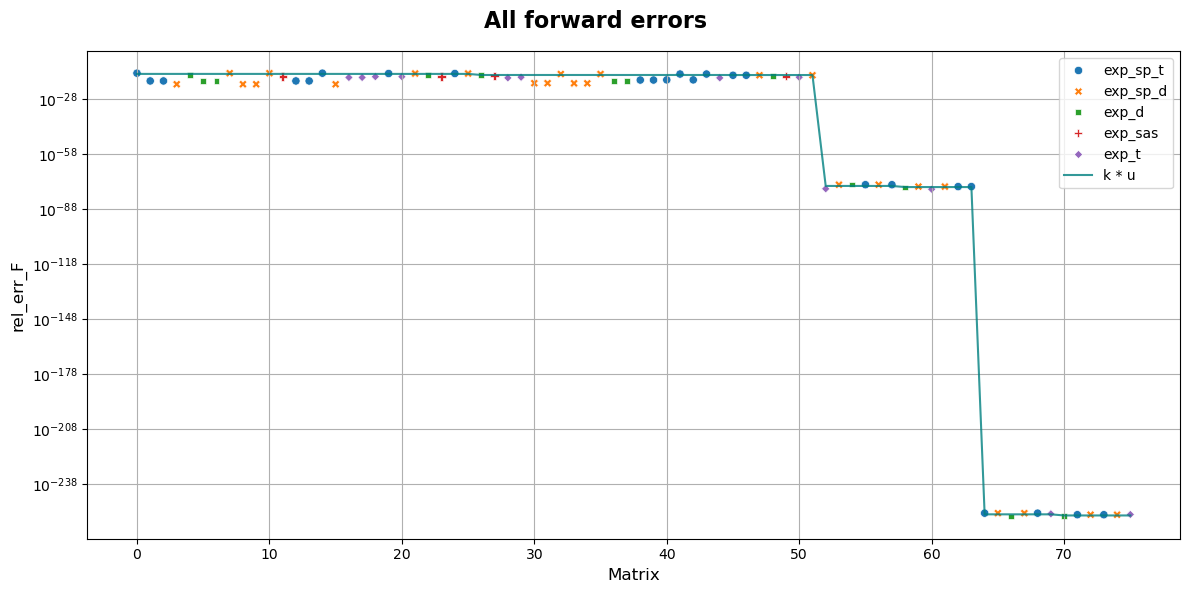

In [17]:
#from utilities import produce_plot

fig, ax = plt.subplots(figsize=(12,6))
fig.suptitle("All forward errors", fontsize=16, fontweight="bold")

produce_plot(df, ax)

plt.tight_layout()
plt.show()

In [18]:
wrk_precs = df["precision"].unique()
wrk_precs

array([ 53, 256, 851])

In [19]:
for p in wrk_precs:
    print(df.loc[df["precision"] == p, "epsilon"].unique())

[2.22044605e-16]
[2.22044605e-16 1.72723371e-77]
[2.22044605e-016 1.33199835e-256]


Vediamo i plots separati per precisione

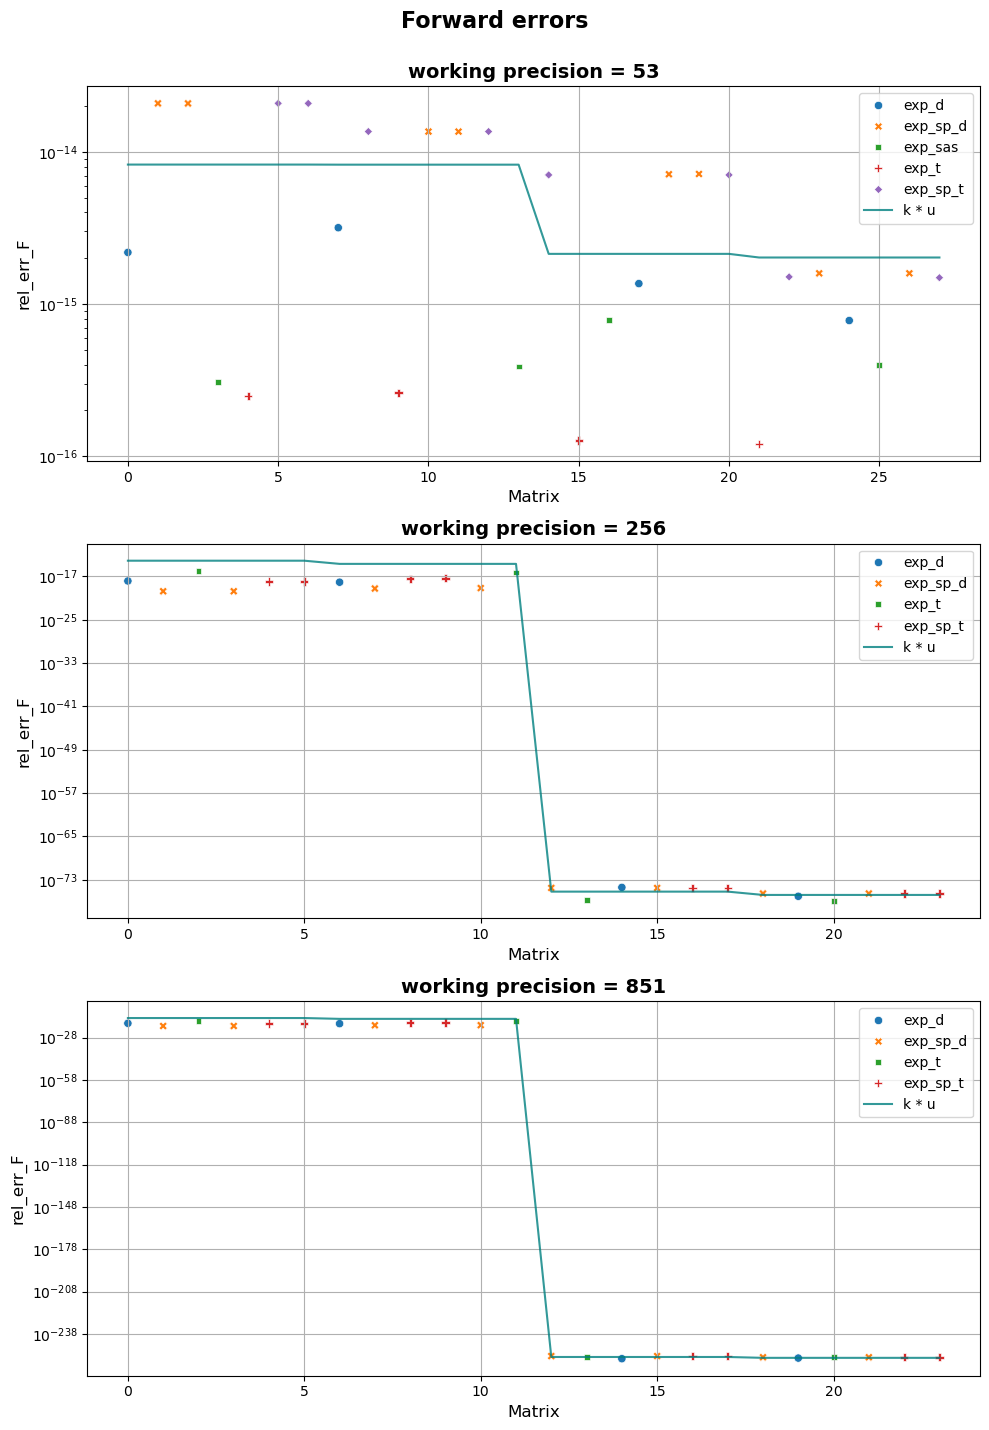

In [20]:
WRK_PRECS = df["precision"].unique()

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors", fontsize=16, fontweight="bold")

for i, wp in enumerate(WRK_PRECS):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    produce_plot(df_inn, axs[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Boh a occhio sembrano grosso modo gli stessi risultati degli autori